The data from Kaggle is downloaded from this (https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset) dataset. The dataset is labelled through folders, however the number of images in each folder is not the same. This could affect the training of the machine learning model, therefore the data must be organized first. If there were only a few hundred images in total, this would be as simple as dragging and dropping, but each folder contains more than one thousand images,so we developed two scripts to help handle this data.

The first script determines the classes (folders) and the number of files for each class using pandas python package to parse the data into a readable table format. This script can be executed below (optional).

In [2]:
import os
import pandas as pd

data_dir = 'data/original_dataset/bloodcells_dataset' #this is the path to the unzipped labelled dataset

classes = os.listdir(data_dir) # using os to list the folder names A.K.A. the classes

data_dist = pd.DataFrame(columns=["Classes", "# of Images"]) #making the table with pandas package

for blood in classes: #a simple for loop that checks every class and counts number of files
    pth = os.path.join(data_dir,blood)
    lst = os.listdir(pth)
    file_no = len(lst)
    data_dist.loc[len(data_dist)] = [blood, file_no]

print(data_dist)

        Classes  # of Images
0      basophil         1218
1    eosinophil         3117
2  erythroblast         1551
3            ig         2895
4    lymphocyte         1214
5      monocyte         1420
6    neutrophil         3329
7      platelet         2348


The second script functions to randomly select images from the original dataset and copy them to an organized directory. This script ensures that there is an equal amount of files for each class and also removes any bias by selecting random images from each class. The second script can be executed below:

In [3]:
import os
import shutil
import random

def take_images(source, destination, number_of_images):

    if not os.path.exists(destination): #make the new directory if it doesnt already exist!!
        os.makedirs(destination)

    list_of_classes = os.listdir(source)

    for blood_class in list_of_classes: #for loop cycles through each class
        blood_class_current_path = os.path.join(source, blood_class)

        if os.path.isdir(blood_class_current_path): #if the actual class exists in the source directory
            
            destination_path = os.path.join(destination, blood_class)
            os.makedirs(destination_path, exist_ok=True) #make the new destination

            #randomly copy a certain number of images from the images in the class
            images_in_class = os.listdir(blood_class_current_path)
            current_number_of_images = len(images_in_class)

            # this line makes sure that the number of images to be copied is less than the current number of images
            # and if not, will default to the current number of images in the folder
            # this helps avoid any issues with the script incase the number of images is not enough
            numberOfImagesToBeCopied = min(current_number_of_images,number_of_images)

            copied_images = random.sample(images_in_class, numberOfImagesToBeCopied)

            for image_name in copied_images:

                current_image_path = os.path.join(blood_class_current_path, image_name)
                copy_image_to_this_path = os.path.join(destination_path, image_name)

                shutil.copy2(current_image_path,copy_image_to_this_path)
            
            number_of_copied_images = len(copied_images)

            print(f"Copied {number_of_copied_images} images from {blood_class}")
    print("All Classes were copied")

originalDataset = 'data/original_dataset/bloodcells_dataset' #the location of the downloaded dataset
organizedDataDir = 'data/Organized_Dataset' #determines the location and name of the organized dataset
numberOfImages = 1200 #determines the number of images to be copied for each class

take_images(originalDataset,organizedDataDir,numberOfImages) # running variables though the function

Copied 1200 images from basophil
Copied 1200 images from eosinophil
Copied 1200 images from erythroblast
Copied 1200 images from ig
Copied 1200 images from lymphocyte
Copied 1200 images from monocyte
Copied 1200 images from neutrophil
Copied 1200 images from platelet
All Classes were copied


Now the first script can be executed again, this time with the organized dataset to confirm that the correct number of images has been copied (optional).

In [4]:
import os
import pandas as pd

data_dir = 'data/Organized_Dataset' #this is the path to the organized dataset

classes = os.listdir(data_dir) # using os to list the folder names A.K.A. the classes

data_dist = pd.DataFrame(columns=["Classes", "# of Images"]) #making the table with pandas package

for blood in classes: #a simple for loop that checks every class and counts number of files
    pth = os.path.join(data_dir,blood)
    lst = os.listdir(pth)
    file_no = len(lst)
    data_dist.loc[len(data_dist)] = [blood, file_no]

print(data_dist)

        Classes  # of Images
0      basophil         1200
1    eosinophil         1200
2  erythroblast         1200
3            ig         1200
4    lymphocyte         1200
5      monocyte         1200
6    neutrophil         1200
7      platelet         1200


The data has been organized, which means the machine model can be trained. This project makes use of Googles' machine learning platform TensorFlow (https://www.tensorflow.org/), which provides tools for creating and testing a machine learning models.

The training and validation data must first be determined using the TensorFlow Keras module. The validation split will be set to 0.2, meaning that 20% of the data will be used as validation and the remaining 80% will be used for training.

In [7]:
import tensorflow as tf 

# directory to the organized data
TypeBloodCell = os.listdir(data_dir)


train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180,180),
    batch_size=16
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180,180),
    batch_size=16
)

Found 9600 files belonging to 8 classes.
Using 7680 files for training.
Found 9600 files belonging to 8 classes.
Using 1920 files for validation.


Now that training and validation data has been determined the model can be created. The model created for this project is a Convolutional Neural Network (CNN) using the ReLU (Rectified Linear Unit) actvation function. Further details regarding the layers and their functions can be read in the methodology section of the mini-project report.

DISCLAIMER: The following code may take a while to execute depending on the specifications of the device running the code and has been optimized to run on the following spcifications:

RAM: 16 GB

CPU: 13th Gen Intel Core i5-1340P

In [40]:
from tensorflow.keras import layers #the module in tensorflow used to make convolutional layers

classes = train_data.class_names
print(f"classes: {classes}")

# configuring performance (according to the tensorflow manual)
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)


classes_no = len(classes)
## The actual model
model = tf.keras.Sequential([

    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(), # filters, kernel size, padding, activation
    
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(classes_no)
])


# compile the model and train it (according to tensorflow manual)
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)

epochs = 10 #number of times the training is repeated
history = model.fit(
  train_data,
  validation_data=val_data,
  epochs=epochs
) # this variable collects the training data (such as accuracy per epoch)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

To visulize the model training results, Matplotlib is used according to the TensorFlow manual. Additionally, the data is also converted into a .csv file so that it may be processed through other softwares.

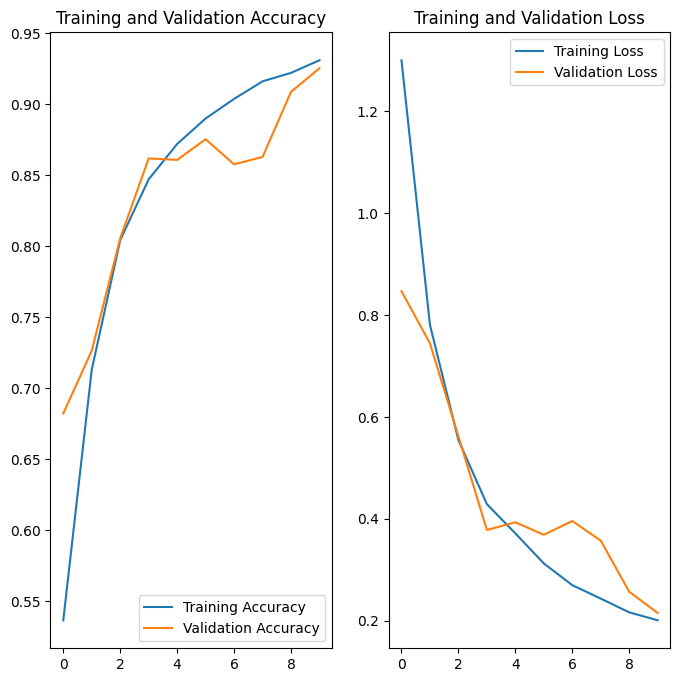

In [9]:
import matplotlib.pyplot as plt 

his = history.history #history of the model trainning

acc = his["accuracy"]
val_acc = his["val_accuracy"]

loss = his["loss"]
val_loss = his['val_loss']

epoch_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc, label='Training Accuracy')
plt.plot(epoch_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss, label='Training Loss')
plt.plot(epoch_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# make results folder and save the history as .csv

history_dataframe = pd.DataFrame(his)
filename = "model_history.csv"
results_folder = "results"

if not os.path.exists(results_folder):
    os.makedirs(results_folder)

results_destination_path = os.path.join(results_folder,filename)

history_dataframe.to_csv(results_destination_path)

Now that the model has been trained, it can be tested with new data. The testing data is selected from the 'data/Testing' folder. Files can be inserted into this folder, prferebly .JPG files with unique names. 

In [ ]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont

test_img_path = 'data/Testing/monocyte_test.JPG'
testing_folder = 'data/Testing'



def make_image(image_path,text,output_dir,file_name):
    open_img = Image.open(image_path)
    draw = ImageDraw.Draw(open_img)

    img_w,img_h = open_img.size
    fsize = img_w*0.05
    font = ImageFont.load_default(size=fsize)
    
    
    draw.text((10,10),text,fill=(0,0,0),font=font)

    output_path = os.path.join(output_dir,file_name)
    #open_img.show() #use to show image directly in a new window
    open_img.save(output_path)

def prediction(test_folder,image_name):
    
    test_image_path = os.path.join(test_folder,image_name)
    image = tf.keras.utils.load_img(
    test_image_path, target_size = (180,180) 
    )
    img_array = tf.keras.utils.img_to_array(image)
    img_array = tf.expand_dims(img_array, 0)
    predict = model.predict(img_array)
    score = tf.nn.softmax(predict[0])

    text_result = "{} is most likely {} : {:.2f} percent confidence.".format(image_name,classes[np.argmax(score)], 100 * np.max(score))
    print(text_result)
    return(classes[np.argmax(score)], 100 * np.max(score))

class_result = []
confidence = []
original_file_list = []


for test_images in os.listdir(testing_folder):
    path_to_image = os.path.join(testing_folder,test_images)
    blood_cell, confidnce = prediction(testing_folder,test_images)
    
    original_file_list.append(test_images)
    class_result.append(blood_cell)
    confidence.append(f"{confidnce:.3f}")

    result_text = blood_cell + " " + f"{confidnce:.2f}" + "%"
    filename = "prediction_" + test_images
    result_path = os.path.join(results_folder,filename)

    make_image(path_to_image,result_text,results_folder,filename)

results_table = pd.DataFrame()
results_table["Filename"] = original_file_list
results_table["Prediction"] = class_result
results_table["Confidence"] = confidence

path = os.path.join(results_folder,"result_table.csv")
results_table.to_csv(path)
print(results_table)
final_Message = ""

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
eosinophil2.JPG is most likely eosinophil : 99.99 percent confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Esinophil1.JPG is most likely basophil : 69.03 percent confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Monocyte2.JPG is most likely neutrophil : 97.47 percent confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
monocyte_test.JPG is most likely ig : 92.52 percent confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Platlete.JPG is most likely eosinophil : 90.23 percent confidence.
            Filename  Prediction Confidence
0    eosinophil2.JPG  eosinophil     99.995
1     Esinophil1.JPG    basophil     69.025
2      Monocyte2.JPG  neutrophil     97.468
3  monocyte_test.JPG          ig     92.525
4       Platlete.JPG  eosinophil     90.226
